<a href="https://colab.research.google.com/drive/1tnOvFNgXiLtktiSsltTr0s308LZSsEPJ">Abre este Jupyter en Google Colab</a>

# Regresión Lineal: Coste de un incidente de seguridad

En este ejercicio se explican los fundamentos básicos de la regresión lineal aplicada a un caso de uso sencillo relacionado con la Ciberseguridad.

## Enunciado del ejercicio

El ejercicio consiste en predecir el coste de un incidente de seguridad en base al número de equipos que se han visto afectados. El conjunto de datos es generado de manera aleatoria.

### 0. Imports

In [1]:
# Instalacion de librerías externas
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn

### 1. Generación del conjunto de datos

In [3]:
import numpy as np

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

print("La longitud del conjunto de datos es:", len(X))

La longitud del conjunto de datos es: 100


### 2. Visualización del conjunto de datos

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

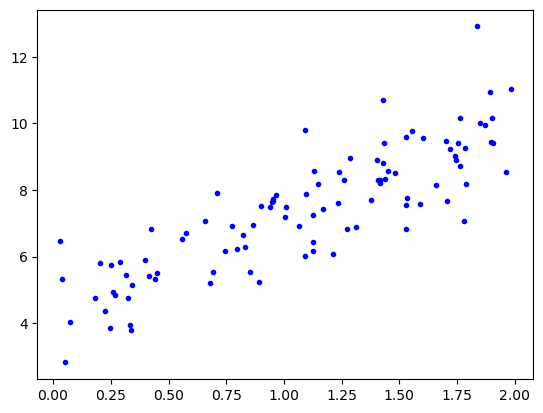

In [13]:
plt.plot(X, y, 'b.')
plt.show()

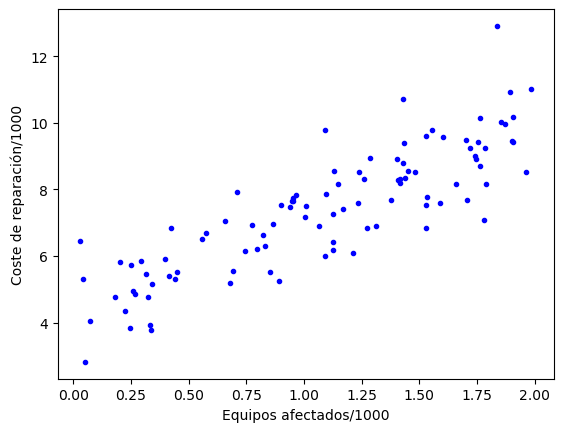

In [17]:
plt.plot(X, y, "b.")
plt.xlabel("Equipos afectados/1000")
plt.ylabel("Coste de reparación/1000")
plt.show()

### 3. Modificación del conjunto de datos (ponerlos en una tabla con pandas)

In [19]:
import pandas as pd

In [32]:
data = {'n_equipos_afectados': X.flatten(), 'coste_reparacion': y.flatten()} # Usamos .flatten porque de numpy, nos queda un array de dimensión (100,1), y pandas necesita un array de una única dimensión (100,)
df = pd.DataFrame(data)
df.head(10)

,n_equipos_afectados,coste_reparacion
0,0.201332,5.815292
1,1.213398,6.076613
2,0.851043,5.522331
3,1.530468,9.600324
4,0.833357,6.294493
5,1.555048,9.783115
6,0.677840,5.190507
7,0.226719,4.353054
8,1.431880,9.408612
9,1.983728,11.022944


In [36]:
# Escalado del número de equipos afectados
df['n_equipos_afectados'] = df['n_equipos_afectados']*1000
df['n_equipos_afectados'] = df['n_equipos_afectados'].astype(int) # Es una conversión de datos ya que de primeras el dataframe tiene Strings. Lo pasamos a enteros

# Escalado del coste
df['coste_reparacion'] = df['coste_reparacion']*1000
df['coste_reparacion'] = df['coste_reparacion'].astype(int)

# Mostrar datos de las diez primeras filas
df.head(10)

,n_equipos_afectados,coste_reparacion
0,201,5815
1,1213,6076
2,851,5522
3,1530,9600
4,833,6294
5,1555,9783
6,677,5190
7,226,4353
8,1431,9408
9,1983,11022


<function matplotlib.pyplot.show(close=None, block=None)>

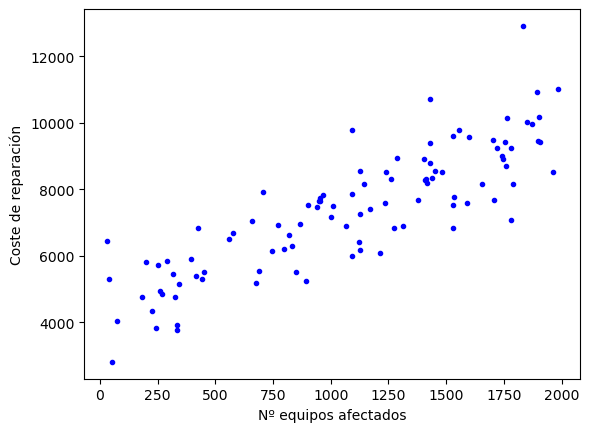

In [40]:
# Representación gráfica del conjunto de datos
plt.plot(df['n_equipos_afectados'], df['coste_reparacion'], 'b.')
plt.xlabel('Nº equipos afectados')
plt.ylabel('Coste de reparación')
plt.show

### 4. Construcción del modelo

In [42]:
from sklearn.linear_model import LinearRegression

In [46]:
# Construcción del modelo y ajuste de la función hipótesis
# 1. Instanciar el objeto de LinearRegression:
lin_reg = LinearRegression()
# 2. Entrenar el modelo con la función .fit(datos_entrada, salida) y el dataset
# OJO. Tenemos que convertir de pandas a numpy de nuevo. Para extraer los valores del diccionario se utiliza .values. También, en las características
# (primer atributo de .fit), espera una matriz (n_samples, n_features). En mi caso será de (100,1) porque solo tenemos una característica de entrada. 
# Para ello se utiliza .reshape(-1,1). El -1 indica que el número de filas debe ser calculado automáticamente en función del número de elementos, y 
# el 1 indica que quieres que sea una columna.
lin_reg.fit(df['n_equipos_afectados'].values.reshape(-1,1), df['coste_reparacion'].values) 

LinearRegression()

In [48]:
# Parámetro theta 0
lin_reg.intercept_

4339.081837259451

In [52]:
# Parámetro theta 1
lin_reg.coef_
# Aquí nos saldrá un array de thetas por cada característica que tuviéramos en nuestro modelo. Como solo tenemos una (n_equipos_afectados), nos devuelve un array de un elemento.

array([2.81967829])

In [56]:
# Predicción para el valor mínimo y máximo del conjunto de datos de entrenamiento para representar la gráfica
X_min_max = np.array([[df["n_equipos_afectados"].min()], [df["n_equipos_afectados"].max()]])
y_train_pred = lin_reg.predict(X_min_max) # Vamos a predecir dos valores a la vez, y sabemos que en X_min_max el primer valor es el mínimo y el otro el máximo
y_train_pred

array([4420.85250771, 9930.50388901])

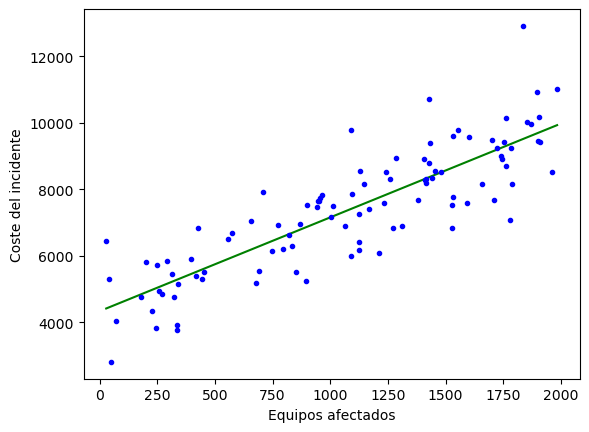

In [62]:
# Representación gráfica de la función hipótesis generada
plt.plot(X_min_max, y_train_pred, "g-")
plt.plot(df['n_equipos_afectados'], df['coste_reparacion'], "b.")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.show()

### 5. Predicción de nuevos ejemplos

In [78]:
# Creamos el array numpy del/de los valores que queremos predecir
x_new = np.array([[1300]]) # Forma (1, 1), una muestra y una característica
# Predicción del coste que tendría el incidente
coste = lin_reg.predict(x_new)

print("El coste del incidente sería:", int(coste[0]), "€")

El coste del incidente sería: 8004 €


In [ ]:
# Mostrar resultados

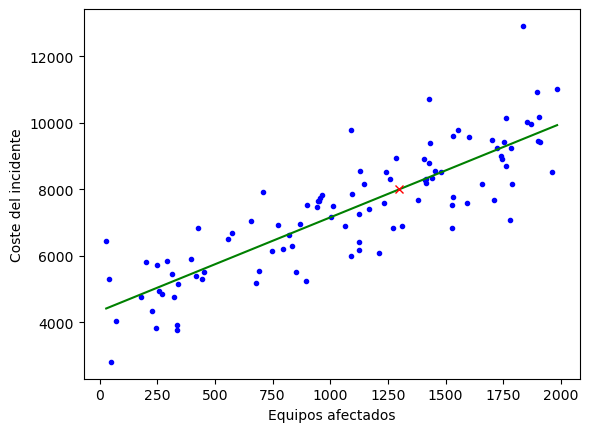

In [80]:
plt.plot(df['n_equipos_afectados'], df['coste_reparacion'], "b.")
plt.plot(X_min_max, y_train_pred, "g-")
plt.plot(x_new, coste, "rx")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.show()